In [1]:
import pandas as pd

# URL of the dataset
url = 'https://raw.githubusercontent.com/prof-apartida/data-exercises/refs/heads/main/Advertising_2.csv'

# Read the CSV file into a pandas DataFrame
df = pd.read_csv(url)

# Display the first 5 rows of the DataFrame
display(df.head())

,TV,Billboards,Radio,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


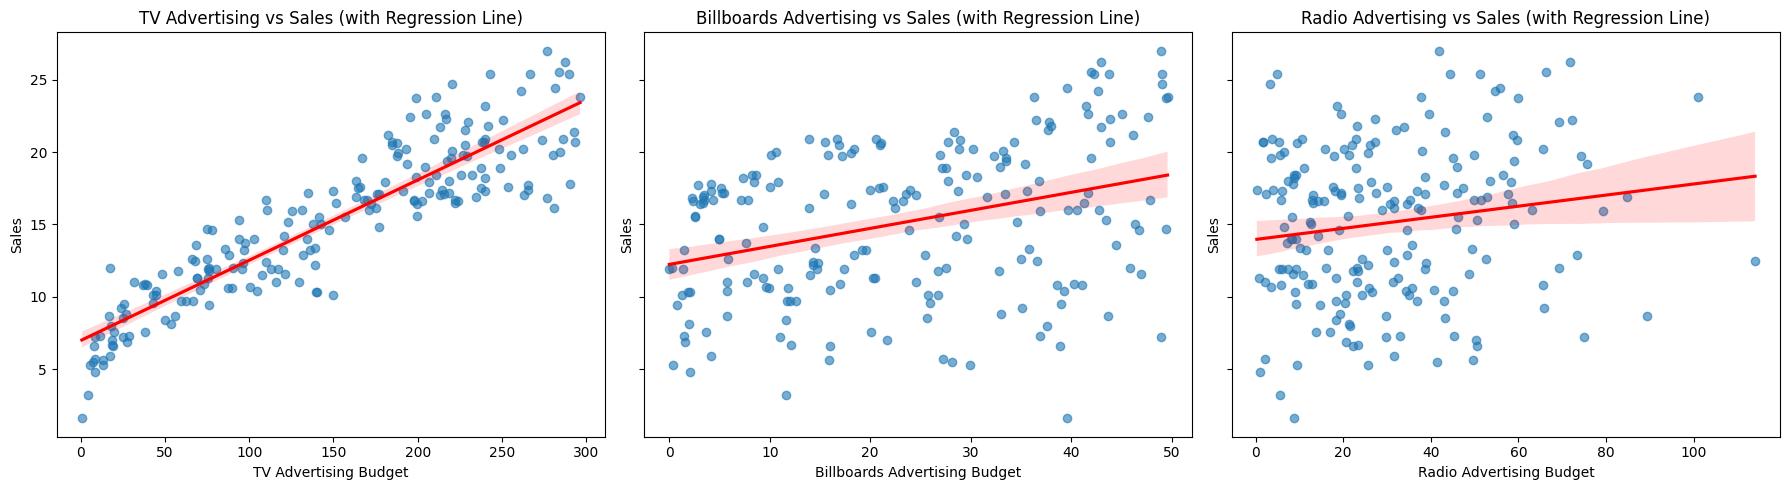

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a figure with subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

# Scatter plot for TV vs Sales with regression line
sns.regplot(x='TV', y='Sales', data=df, ax=axes[0], scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
axes[0].set_title('TV Advertising vs Sales (with Regression Line)')
axes[0].set_xlabel('TV Advertising Budget')
axes[0].set_ylabel('Sales')

# Scatter plot for Billboards vs Sales with regression line
sns.regplot(x='Billboards', y='Sales', data=df, ax=axes[1], scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
axes[1].set_title('Billboards Advertising vs Sales (with Regression Line)')
axes[1].set_xlabel('Billboards Advertising Budget')
axes[1].set_ylabel('Sales')

# Scatter plot for Radio vs Sales with regression line
sns.regplot(x='Radio', y='Sales', data=df, ax=axes[2], scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
axes[2].set_title('Radio Advertising vs Sales (with Regression Line)')
axes[2].set_xlabel('Radio Advertising Budget')
axes[2].set_ylabel('Sales')

plt.tight_layout()
plt.show()

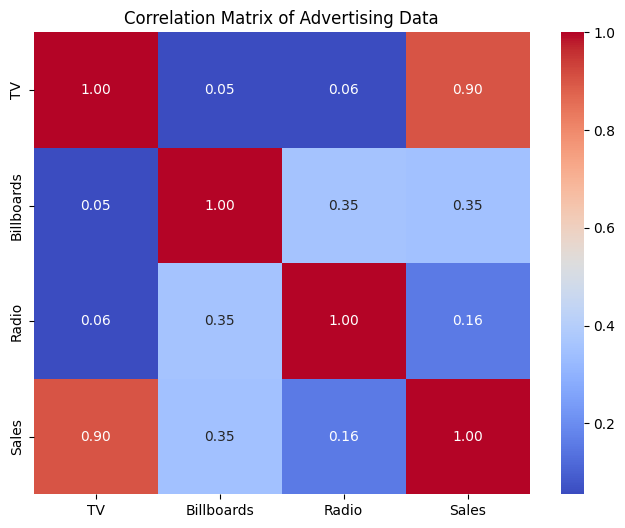

In [4]:
# Calculate the correlation matrix
corr_matrix = df.corr()

# Plot the correlation matrix as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Advertising Data')
plt.show()

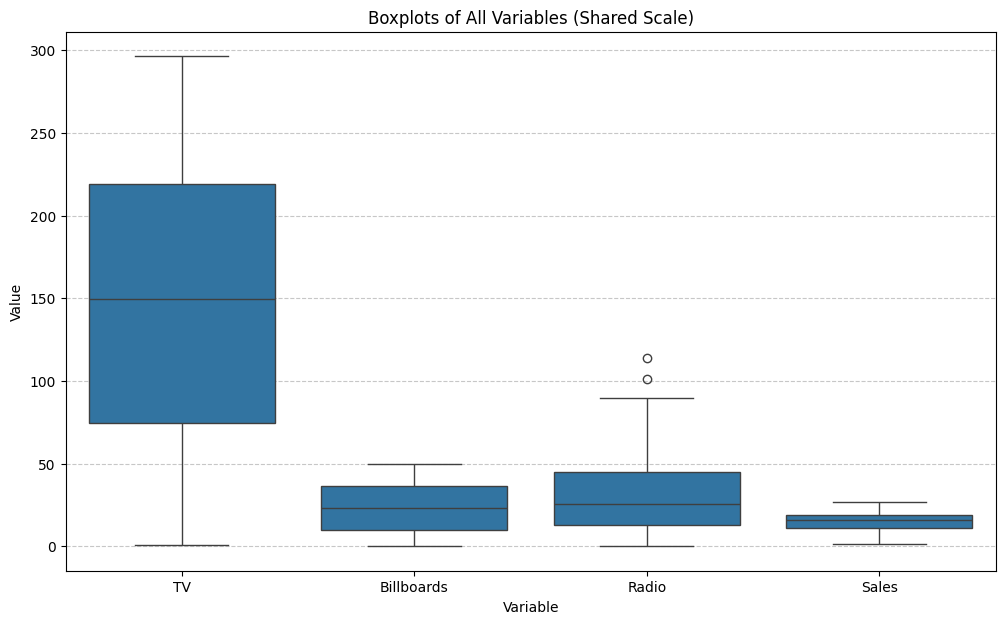

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Melt the DataFrame to long format for easier plotting of all variables
df_melted = df.melt(var_name='Variable', value_name='Value')

# Create boxplots for all variables with a shared y-axis scale
plt.figure(figsize=(12, 7))
sns.boxplot(x='Variable', y='Value', data=df_melted)
plt.title('Boxplots of All Variables (Shared Scale)')
plt.xlabel('Variable')
plt.ylabel('Value')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [6]:
# Display descriptive statistics for the DataFrame
display(df.describe())

,TV,Billboards,Radio,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,15.130500
std,85.854236,14.846809,21.778621,5.283892
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,11.000000
50%,149.750000,22.900000,25.750000,16.000000
75%,218.825000,36.525000,45.100000,19.050000
max,296.400000,49.600000,114.000000,27.000000


In [8]:
import statsmodels.formula.api as smf

# Define the OLS model formula
# Sales is the dependent variable, and TV, Billboards, and Radio are independent variables
model_formula = 'Sales ~ TV + Billboards + Radio'

# Create and fit the OLS model
ols_model = smf.ols(formula=model_formula, data=df).fit()

# Display the model summary
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.903
Model:                            OLS   Adj. R-squared:                  0.901
Method:                 Least Squares   F-statistic:                     605.4
Date:                Mon, 20 Jul 2026   Prob (F-statistic):           8.13e-99
Time:                        12:10:58   Log-Likelihood:                -383.34
No. Observations:                 200   AIC:                             774.7
Df Residuals:                     196   BIC:                             787.9
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      4.6251      0.308     15.041      0.0

In [9]:
model_formula = 'Sales ~ TV + Billboards'

# Create and fit the OLS model
ols_model = smf.ols(formula=model_formula, data=df).fit()

# Display the model summary
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.903
Model:                            OLS   Adj. R-squared:                  0.902
Method:                 Least Squares   F-statistic:                     912.7
Date:                Mon, 20 Jul 2026   Prob (F-statistic):          2.39e-100
Time:                        12:21:29   Log-Likelihood:                -383.34
No. Observations:                 200   AIC:                             772.7
Df Residuals:                     197   BIC:                             782.6
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      4.6309      0.290     15.952      0.0

In [12]:
1000*0.0544

54.4

In [13]:
1000*0.1072

107.2

In [10]:
model_formula = 'Sales ~ Billboards + Radio'

# Create and fit the OLS model
ols_model = smf.ols(formula=model_formula, data=df).fit()

# Display the model summary
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.124
Model:                            OLS   Adj. R-squared:                  0.115
Method:                 Least Squares   F-statistic:                     13.89
Date:                Mon, 20 Jul 2026   Prob (F-statistic):           2.28e-06
Time:                        12:22:15   Log-Likelihood:                -603.03
No. Observations:                 200   AIC:                             1212.
Df Residuals:                     197   BIC:                             1222.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     12.0607      0.728     16.556      0.0

In [11]:
model_formula = 'Sales ~ TV  + Radio'

# Create and fit the OLS model
ols_model = smf.ols(formula=model_formula, data=df).fit()

# Display the model summary
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.824
Model:                            OLS   Adj. R-squared:                  0.822
Method:                 Least Squares   F-statistic:                     460.0
Date:                Mon, 20 Jul 2026   Prob (F-statistic):           5.89e-75
Time:                        12:22:43   Log-Likelihood:                -442.70
No. Observations:                 200   AIC:                             891.4
Df Residuals:                     197   BIC:                             901.3
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      6.2347      0.375     16.607      0.0